In [9]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import torch
from src.model import VGG16_FCN32s

model = VGG16_FCN32s(num_classes=32)

inp = torch.randn(1, 3, 360, 480)

output = model(inp)

print(f"Output shape: {output.shape}")

Output shape: torch.Size([1, 32, 352, 480])


In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
from src.model import VGG16_FCN32s
from src.dataset import CamVidDataset
import sys
import os
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from src.utils import label_accuracy_score

sys.path.append(os.path.abspath(".."))


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model = VGG16_FCN32s(num_classes=32).to(device)

model.load_state_dict(torch.load("../model/best_model.pth", map_location=device))
model.eval()

t = transforms.Compose([
    transforms.Resize((352, 480)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

dict_path = "../data/CamVid/class_dict.csv"
val_ds = CamVidDataset("../data/CamVid/val", "../data/CamVid/val_labels", dict_path, transform=t)

In [ ]:
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2)

model.eval()
preds, gts = [], []

with torch.no_grad():
    for images, masks in tqdm(val_loader, desc="Validation"):
        images = images.to(device)
        outputs = model(images)
        
        pred = outputs.argmax(dim=1).cpu().numpy()
        preds.append(pred)
        gts.append(masks.numpy())

acc, miou = label_accuracy_score(gts, preds, n_class=32)

print(f"Overall Pixel Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"Mean IoU (mIoU)        : {miou:.4f} ({miou*100:.2f}%)")

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

FINAL MODEL PERFORMANCE
Overall Pixel Accuracy : 0.8676 (86.76%)
Mean IoU (mIoU)        : 0.3305 (33.05%)


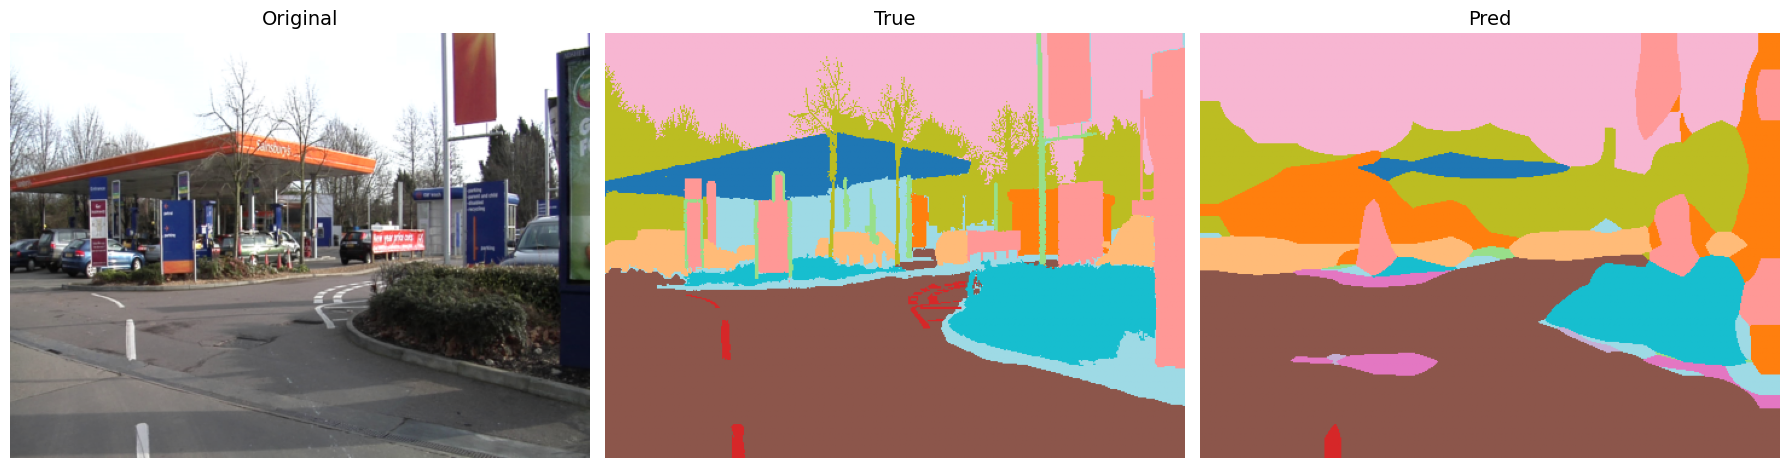

In [7]:
image_index = 12
img, mask = val_ds[image_index]
img_input = img.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img_input)
    pred = output.argmax(dim=1).squeeze(0).cpu().numpy()

img_vis = inv_normalize(img).permute(1, 2, 0).numpy()
img_vis = np.clip(img_vis, 0, 1)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(img_vis)
axs[0].set_title("Original", fontsize=14)
axs[0].axis("off")

axs[1].imshow(mask.numpy(), cmap="tab20", vmin=0, vmax=31)
axs[1].set_title("True", fontsize=14)
axs[1].axis("off")

axs[2].imshow(pred, cmap="tab20", vmin=0, vmax=31)
axs[2].set_title(f"Pred", fontsize=14)
axs[2].axis("off")

plt.tight_layout()
plt.show()